In [46]:
from QuantumMST import protein_structure, scatterer
import numpy as np
import scipy.linalg as la
import scipy.integrate
import matplotlib.pyplot as plt

In [47]:
def j_1d(l, z):
    return np.cos(z) if (l==0) else np.sin(z)

def h_1d(l, z):
    return (np.cos(z) + 1j * np.sin(z)) if l == 0 else (np.sin(z) - 1j * np.cos(z))

def calc_R_k(E, V, r, l):
    if(E>V):
        k = np.sqrt(E-V)
        if(l==0): R = np.cos(k*r)
        else: R = np.sin(k*r)
    else:
        k = np.sqrt(V-E)
        if(l==0): R = np.cosh(k*r)
        else: R = np.sinh(k*r)

    return R, k

#calculate b and c
def Psi_components(structure: protein_structure):
    sec_matrix = structure.secular_matrix()
    scatterer_num = len(structure.scatterers)
    energy = structure.energy

    _, _, Vh = np.linalg.svd(sec_matrix)
    #from secular equantion
    B = Vh[-1, :]
    C = np.zeros_like(B, dtype=complex)

    index = 0
    for i_sc in range(scatterer_num):
        for l in [0, 1]:
            s = structure.scatterers[i_sc]
            V_sc = s.V
            r_sc = s.r
            R_loc, k = calc_R_k(energy, V_sc, r_sc, l)
            z = k * r_sc

            #(5) notes
            C[index] = (B[index]*(h_1d(l, z)+s.calc_ml(energy, i_sc) *j_1d(l, z)))/R_loc
            index+=1

    return B, C

#inside which scatterer we are or -1 if outside
def region(x, structure: protein_structure):
    scatterer_num = len(structure.scatterers)
    
    for i in range(scatterer_num):
        x_s = structure.positions[i]
        r = structure.scatterers[i].r
        if np.abs(x - x_s) <= r:
            return i
            
    return -1

def Psi(x, structure: protein_structure):
    B, C = Psi_components(structure)
    scatterer_num = len(structure.scatterers)
    energy = structure.energy
    k_ext = np.sqrt(energy + 0j)
    
    reg = int(region(x, structure))
    
    #outside
    if reg <0:

        psi_n = 0.0 + 0j
        index = 0
        for i_sc in range(scatterer_num):
            dx = x - structure.positions[i_sc]
            r_n = np.abs(dx)
            z = k_ext * r_n
            s = structure.scatterers[i_sc]
            
            for l in [0, 1]:
                if (l == 0): Y = 1/np.sqrt(2)  
                else: Y = np.sign(dx)/np.sqrt(2)
                psi_n += B[index] * (h_1d(l, z)) * Y #(4) Butler
                index += 1
        return psi_n
    #inside
    else:
        psi_n = 0.0 + 0j
        dx = x - structure.positions[reg]
        r_n = np.abs(dx)
        s = structure.scatterers[reg]
        
        for l in [0, 1]:
            index = reg * 2 + l
            R_loc, _ = calc_R_k(energy, s.V, r_n, l)
            if (l == 0): Y = 1/np.sqrt(2)  
            else: Y = np.sign(dx)/np.sqrt(2)
            psi_n += C[index] * R_loc * Y #(4) notes
            
        return psi_n




In [48]:
def plot_wavefunction(array_x, V, structure: protein_structure):
        title_font = {
        'fontname': 'STIXGeneral',
        'size': 13,
        'weight': 'semibold',
        'color': 'black'
        }

        axis_font = {
                'fontname': 'STIXGeneral',
                'size': 13,    
        }
        # psi = np.array([calc_psi(x, structure) for x in array_x])
        psi = np.array([Psi(x, structure) for x in array_x])

        integral = scipy.integrate.simpson((np.abs(psi)**2), x = array_x)
        norm_psi = psi/np.sqrt(integral)

        a = np.max(np.abs(norm_psi))*1.1
        # print(f"a = {a}")
        V = np.array(V)
        plt.plot(array_x, norm_psi, color='black')
        plt.axhline(0, ls='--', color='black')
        plt.fill_between(array_x, -a, a, where=V<0, color='red', alpha=0.1, hatch="//")
        plt.ylim(-a, a)
        plt.title(f"Wavefunction for energy {structure.energy:4f} Ry \nfor two-scatterer system", fontdict=title_font)
        plt.xlabel("x[$a_0$]", fontdict=axis_font)
        plt.ylabel(r"$\Psi$", fontdict=axis_font)
        plt.show()

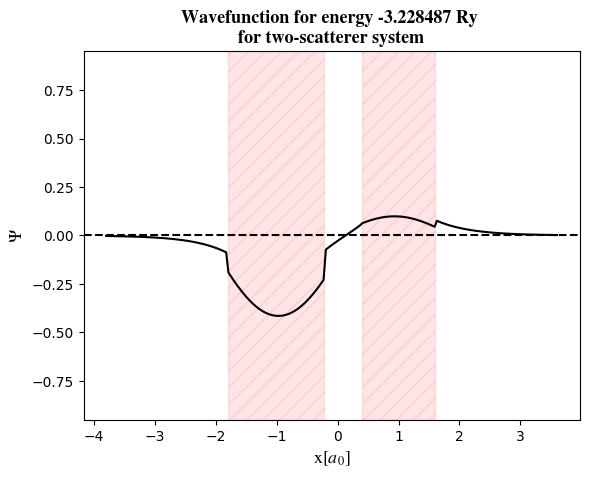

In [49]:
exact_e1 = -3.22848704
exact_e2 = -3.949901757
structure = protein_structure(exact_e1, reference_system=1)
V, array_x = structure.potential()
plot_wavefunction(array_x, V, structure)

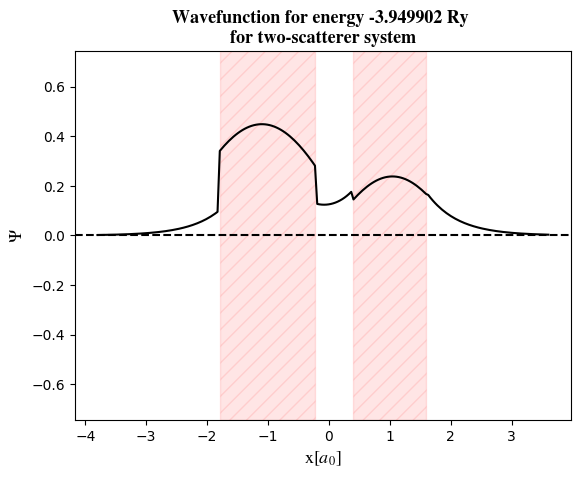

In [50]:
structure = protein_structure(exact_e2, reference_system=1)
V, array_x = structure.potential()
plot_wavefunction(array_x, V, structure)

In [51]:
rA, VA, xA = 0.8, -5, -1
rB, VB, RAB = 0.6, -6, 2

s1 = scatterer(r=rA, V=VA)

structure = protein_structure(-3.55212769, [s1, s1, s1], [xA, xA+RAB, xA+2*RAB])
V, array_x = structure.potential()
plot_wavefunction(array_x, V, structure)


UnboundLocalError: local variable 'R' referenced before assignment